In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv("D:\\25-26\\Seminar Presentation Topic\\SEM-II\\DSBDAL\\Final All Programs of DSBDAL\\2\\MyExp2Academic-Performance-Dataset.csv")
df

,Rollno,Name,Gender,Branch,Attendence,Phy_marks,Che_marks,EM1_marks,PPS_marks,SME_marks,Total Marks,Percentage
0,1,Mohammed,M,Comp,72.0,62.0,98.0,63.0,89.0,36.0,368,73.6
1,2,Reyansh,M,IT,58.0,62.0,83.0,83.0,88.0,34.0,350,70.0
2,3,Aarav,M,IT,57.0,-20.0,100.0,NaN,56.0,36.0,192,38.4
3,4,Atharv,M,IT,60.0,89.0,83.0,70.0,33.0,23.0,298,59.6
4,5,Vivaan,M,Comp,85.0,90.0,NaN,78.0,23.0,56.0,247,49.4
5,6,Advik,M,ENTC,94.0,99.0,84.0,100.0,56.0,99.0,438,87.6
6,7,Ansh,M,ENTC,98.0,88.0,95.0,81.0,78.0,78.0,420,84.0
7,8,Ishaan,M,ENTC,75.0,66.0,51.0,83.0,-99.0,76.0,192,38.4
8,9,Dhruv,M,ENTC,63.0,NaN,NaN,97.0,56.0,55.0,208,41.6
9,10,Siddharth,M,ENTC,96.0,67.0,78.0,95.0,NaN,98.0,338,67.6


In [3]:
df.shape

(20, 12)

In [4]:
df.dtypes

Rollno           int64
Name            object
Gender          object
Branch          object
Attendence     float64
Phy_marks      float64
Che_marks      float64
EM1_marks      float64
PPS_marks      float64
SME_marks      float64
Total Marks      int64
Percentage     float64
dtype: object

In [17]:
df['Phy_marks'].min()

66.2

In [18]:
df['Phy_marks'].max()

100.0

In [6]:
df.isnull().sum()

Rollno         0
Name           2
Gender         0
Branch         0
Attendence     0
Phy_marks      1
Che_marks      3
EM1_marks      2
PPS_marks      1
SME_marks      0
Total Marks    0
Percentage     0
dtype: int64

In [7]:
df['PPS_marks'] = df['PPS_marks'].astype("Int64")
df.dtypes

Rollno           int64
Name            object
Gender          object
Branch          object
Attendence     float64
Phy_marks      float64
Che_marks      float64
EM1_marks      float64
PPS_marks        Int64
SME_marks      float64
Total Marks      int64
Percentage     float64
dtype: object

In [8]:
# Handle missing values (e.g., fill with mean for numeric columns)
df['Phy_marks'] = df['Phy_marks'].fillna(df['Phy_marks'].mean())
df['Che_marks'] = df['Che_marks'].fillna(df['Che_marks'].mean())

# Confirm replacement
print("\nAfter handling missing values:\n", df)


After handling missing values:
     Rollno       Name Gender Branch  Attendence  Phy_marks   Che_marks  \
0        1   Mohammed      M   Comp        72.0  62.000000   98.000000   
1        2    Reyansh      M     IT        58.0  62.000000   83.000000   
2        3      Aarav      M     IT        57.0 -20.000000  100.000000   
3        4     Atharv      M     IT        60.0  89.000000   83.000000   
4        5     Vivaan      M   Comp        85.0  90.000000   80.764706   
5        6      Advik      M   ENTC        94.0  99.000000   84.000000   
6        7       Ansh      M   ENTC        98.0  88.000000   95.000000   
7        8     Ishaan      M   ENTC        75.0  66.000000   51.000000   
8        9      Dhruv      M   ENTC        63.0  63.421053   80.764706   
9       10  Siddharth      M   ENTC        96.0  67.000000   78.000000   
10      11     Vihaan      M   ENTC        82.0  54.000000   70.000000   
11      12        NaN      M     IT        75.0  64.000000   67.000000   
12   

<Axes: >

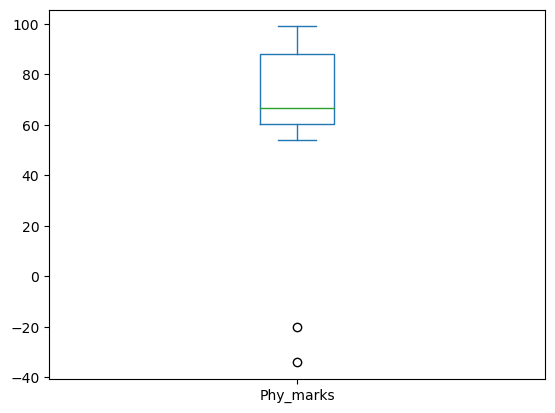

In [9]:
df['Phy_marks'].plot(kind='box')

In [16]:
# Define a function to detect outliers using IQR
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    print(f"\n{column} - Outlier Range: ({lower_bound}, {upper_bound})")
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Remove outliers
df = remove_outliers_iqr(df, 'Phy_marks')
df = remove_outliers_iqr(df, 'Che_marks')

# Reset index after outlier removal
df.reset_index(drop=True, inplace=True)
print("\nData after removing outliers:\n", df)



Phy_marks - Outlier Range: (39.925, 122.925)

Che_marks - Outlier Range: (70.72794117647058, 91.96323529411765)

Data after removing outliers:
    Rollno       Name Gender Branch  Attendence  Phy_marks  Che_marks  \
0       2    Reyansh      M     IT        58.0       72.2  83.000000   
1       4     Atharv      M     IT        60.0       92.5  83.000000   
2       5     Vivaan      M   Comp        85.0       93.2  80.764706   
3       6      Advik      M   ENTC        94.0      100.0  84.000000   
4       9      Dhruv      M   ENTC        63.0       73.2  80.764706   
5      10  Siddharth      M   ENTC        96.0       76.0  78.000000   
6      13     Aarush      M     IT        67.0       67.6  81.000000   
7      17    Zaranew      F   Comp        93.0       66.2  80.764706   
8      19      Aarya      F   Comp        72.0       91.8  84.000000   
9      20        NaN      F   Comp        53.0       82.7  81.000000   

   EM1_marks  PPS_marks  SME_marks  Total Marks  Percentage  
